# Segmentation Retrain v2

Fresh training with:
- Aggressive time-based checkpointing (every 5-10 min)
- Stratified train/val/test split across all data sources
- Strong regularization (L2, dropout, augmentation)
- Early stopping on validation IoU
- Per-source generalization testing
- Threshold tuning on validation set only
- Auto-recovery from crashes via history.json

**Goal: IoU > 90% + usable model (low false positives)**

**First:** Run the setup cell below to install dependencies

In [1]:
import subprocess
import sys

# Install dependencies
packages = [
    'segmentation-models-pytorch',
    'torch',
    'torchvision',
    'torchaudio',
    'opencv-python',
    'albumentations',
    'scikit-learn',
    'matplotlib',
    'tqdm'
]

print('Installing dependencies...')
for pkg in packages:
    try:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
    except:
        print(f'Warning: Failed to install {pkg}')

print('Dependencies ready')

Installing dependencies...
Dependencies ready


In [2]:
import os
import sys
import time
import json
from pathlib import Path
from datetime import datetime
from collections import defaultdict

import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Check if running on Colab
try:
    from google.colab import drive
    IN_COLAB = True
    print('Running on Colab - mounting Drive...')
    drive.mount('/content/drive', force_remount=False)
    DRIVE_DIR = Path('/content/drive/MyDrive/HeritagePreservation')
    DATA_DIR = Path('/content/data')
    CKPT_DIR = Path('/content/checkpoints/segmentor_v4')
except:
    IN_COLAB = False
    print('Running locally')
    notebook_dir = Path.cwd()
    project_root = notebook_dir.parent if notebook_dir.name == 'notebooks' else notebook_dir
    DATA_DIR = project_root / 'data'
    if not DATA_DIR.exists():
        DATA_DIR = Path('/Users/user/Desktop/Masters/Semester 2/ComputerVision/Deep-LearningHeritagePreservation/data')

# Checkpoint directory
if IN_COLAB:
    CHECKPOINT_DIR = Path('/content/checkpoints/segmentor_retrain')
else:
    CHECKPOINT_DIR = Path.cwd().parent / 'segmentation_checkpoint_retrain'

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Data dir      : {DATA_DIR}')
print(f'Data exists   : {DATA_DIR.exists()}')
print(f'Checkpoint dir: {CHECKPOINT_DIR}')

Device: cuda
Running on Colab - mounting Drive...
Mounted at /content/drive
Data dir      : /content/data
Data exists   : False
Checkpoint dir: /content/checkpoints/segmentor_retrain


## Data Loading

In [3]:
import zipfile
import shutil
import random

DATA_DIR.mkdir(parents=True, exist_ok=True)

def extract_dataset(zip_name, data_dir, drive_dir):
    """Copy zip to local /content first, then extract — avoids Drive FUSE drops on large files."""
    zip_path = drive_dir / zip_name
    out_name = zip_name.replace('.zip', '')
    out_dir = data_dir / out_name

    if not zip_path.exists():
        print(f'SKIP {zip_name} — not on Drive')
        return
    if out_dir.exists() and any(out_dir.rglob('*.*')):
        print(f'{zip_name}: already extracted, skipping.')
        return

    size_mb = zip_path.stat().st_size / 1e6
    local_zip = Path(f'/content/_tmp_{out_name}.zip')

    print(f'Copying {zip_name} ({size_mb:.0f} MB) to local disk...')
    shutil.copy2(zip_path, local_zip)
    print(f'Extracting...')
    with zipfile.ZipFile(local_zip, 'r') as zf:
        zf.extractall(data_dir)
    local_zip.unlink()
    print(f'  Done.')

for zip_name in ['masonry.zip', 'crackforest.zip', 'historical_crack.zip', 'omnicrack30k.zip']:
    extract_dataset(zip_name, DATA_DIR, DRIVE_DIR)

print('\n' + '='*60 + '\n')

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}
IMG_DIR_NAMES = {'images', 'img', 'image', 'jpegimages', 'rgb', 'data'}
MASK_DIR_NAMES = {'masks', 'mask', 'labels', 'label', 'annotations', 'gts', 'gt'}

def find_image_mask_pairs(root_dir, max_samples=None, seed=42):
    """Recursively find image-mask pairs with flexible naming conventions."""
    root = Path(root_dir)
    pairs = []
    seen = set()

    if not root.exists():
        return pairs

    for img_dir in root.rglob('*'):
        if not img_dir.is_dir() or img_dir.name.lower() not in IMG_DIR_NAMES:
            continue

        parent = img_dir.parent
        mask_dir = None
        for mn in MASK_DIR_NAMES:
            c = parent / mn
            if c.is_dir():
                mask_dir = c
                break

        if mask_dir is None:
            continue

        for img_path in sorted(img_dir.glob('*.*')):
            if img_path.suffix.lower() not in IMG_EXTS:
                continue

            key = str(img_path)
            if key in seen:
                continue

            for ext in ['.png', '.jpg', '.bmp', img_path.suffix]:
                mask_path = mask_dir / f'{img_path.stem}{ext}'
                if mask_path.exists():
                    pairs.append((str(img_path), str(mask_path)))
                    seen.add(key)
                    break

    if max_samples and len(pairs) > max_samples:
        rng = random.Random(seed)
        rng.shuffle(pairs)
        pairs = pairs[:max_samples]

    return pairs

# Load datasets (MASONRY EXCLUDED)
print('Finding image-mask pairs...')
masonry_pairs = []  # SKIP MASONRY
crackforest_pairs = find_image_mask_pairs(DATA_DIR / 'crackforest')

# omnicrack30k: top-level images/ and annotations/
omni_img_dir = DATA_DIR / 'images'
omni_mask_dir = DATA_DIR / 'annotations'
omnicrack_pairs = []
if omni_img_dir.exists() and omni_mask_dir.exists():
    for img_path in sorted(omni_img_dir.rglob('*.*')):
        if img_path.suffix.lower() not in IMG_EXTS:
            continue
        rel = img_path.relative_to(omni_img_dir)
        for ext in ['.png', img_path.suffix, '.jpg']:
            mask_path = omni_mask_dir / rel.parent / f'{img_path.stem}{ext}'
            if mask_path.exists():
                omnicrack_pairs.append((str(img_path), str(mask_path)))
                break
    print(f'omnicrack30k found: {len(omnicrack_pairs)} pairs')
    if len(omnicrack_pairs) > 3000:
        rng = random.Random(42)
        rng.shuffle(omnicrack_pairs)
        omnicrack_pairs = omnicrack_pairs[:3000]

print(f'masonry        : {len(masonry_pairs)} (EXCLUDED)')
print(f'crackforest    : {len(crackforest_pairs)}')
print(f'omnicrack30k   : {len(omnicrack_pairs)}')

total = len(masonry_pairs) + len(crackforest_pairs) + len(omnicrack_pairs)
print(f'\nTotal pairs    : {total}')

Copying masonry.zip (21 MB) to local disk...
Extracting...
  Done.
Copying crackforest.zip (4 MB) to local disk...
Extracting...
  Done.
Copying historical_crack.zip (17 MB) to local disk...
Extracting...
  Done.
Copying omnicrack30k.zip (10604 MB) to local disk...
Extracting...
  Done.


Finding image-mask pairs...
omnicrack30k found: 30017 pairs
masonry        : 0 (EXCLUDED)
crackforest    : 118
omnicrack30k   : 3000

Total pairs    : 3118


In [4]:
# No upsampling — use weighted sampler instead
# Weighted sampler gives masonry/crackforest higher sampling probability

print('Dataset composition (no upsampling):')
print(f'  masonry    : {len(masonry_pairs)}')
print(f'  crackforest: {len(crackforest_pairs)}')
print(f'  omnicrack  : {len(omnicrack_pairs)}')

# Stratified split: ensure train/val/test have balanced source distribution
def stratified_train_val_test_split(pairs, test_size=0.15, val_size=0.15, random_state=42):
    """
    Split into train/val/test while preserving distribution.
    Returns (train_pairs, val_pairs, test_pairs)
    """
    # First split: train+val vs test
    train_val, test = train_test_split(
        pairs, test_size=test_size, random_state=random_state
    )

    # Second split: train vs val (from train_val)
    adjusted_val_size = val_size / (1 - test_size)  # adjust for test split
    train, val = train_test_split(
        train_val, test_size=adjusted_val_size, random_state=random_state
    )

    return train, val, test

# Combine pairs and split (original, no upsampling)
all_pairs = masonry_pairs + crackforest_pairs + omnicrack_pairs
train_pairs, val_pairs, test_pairs = stratified_train_val_test_split(
    all_pairs, test_size=0.15, val_size=0.15
)

print(f'\nTrain: {len(train_pairs)} | Val: {len(val_pairs)} | Test: {len(test_pairs)}')
print(f'Train %: {100*len(train_pairs)/len(all_pairs):.1f}%')
print(f'Val %  : {100*len(val_pairs)/len(all_pairs):.1f}%')
print(f'Test % : {100*len(test_pairs)/len(all_pairs):.1f}%')

# Compute weights for train set (masonry/crackforest get higher weight)
train_weights = []
for img_path, mask_path in train_pairs:
    if 'masonry' in img_path:
        train_weights.append(3.0)  # 3x weight for masonry
    elif 'crackforest' in img_path:
        train_weights.append(3.0)  # 3x weight for crackforest
    else:  # omnicrack
        train_weights.append(1.0)  # 1x weight for omnicrack

print(f'\nTrain set weights:')
print(f'  masonry/crackforest: 3.0x')
print(f'  omnicrack: 1.0x')
print(f'  Weight range: {min(train_weights):.1f}-{max(train_weights):.1f}')

Dataset composition (no upsampling):
  masonry    : 0
  crackforest: 118
  omnicrack  : 3000

Train: 2182 | Val: 468 | Test: 468
Train %: 70.0%
Val %  : 15.0%
Test % : 15.0%

Train set weights:
  masonry/crackforest: 3.0x
  omnicrack: 1.0x
  Weight range: 1.0-3.0


## Augmentation Strategy

In [5]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

def get_transforms(split, img_size=384):
    if split == 'train':
        return A.Compose([
            A.Resize(img_size, img_size),
            # Geometric augmentations (mask-safe)
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.Transpose(p=0.3),
            A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=30,
                               border_mode=cv2.BORDER_REFLECT_101, p=0.5),
            A.ElasticTransform(alpha=120, sigma=6, p=0.4),
            A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.4),
            A.CoarseDropout(max_holes=8, max_height=32, max_width=32,
                            min_holes=1, fill_value=0, p=0.2),
            # Image-only augmentations (applied after, before normalize)
            A.OneOf([
                A.Sharpen(alpha=(0.2, 0.5)),
                A.Emboss(alpha=(0.2, 0.5)),
            ], p=0.4),
            A.OneOf([
                A.GaussNoise(var_limit=(10.0, 50.0)),
                A.GaussianBlur(blur_limit=(3, 5)),
            ], p=0.3),
            # Intensity augmentations (image only)
            A.RandomBrightnessContrast(brightness_limit=0.4, contrast_limit=0.4, p=0.6),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ], is_check_shapes=False)

    # Val/test: minimal, deterministic
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ], is_check_shapes=False)

print('Transforms ready')

Transforms ready


## Dataset Class

In [6]:
_CLAHE = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))

class CrackSegDataset(Dataset):
    def __init__(self, pairs, split='train', img_size=384, transform=None):
        self.pairs = pairs
        self.img_size = img_size
        self.transform = transform or get_transforms(split, img_size)

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        # Read image (CLAHE always applied for contrast enhancement)
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        if img is None:
            raise FileNotFoundError(f'Image not found: {img_path}')
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Apply CLAHE to grayscale
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        clahe_gray = _CLAHE.apply(gray)
        img = cv2.cvtColor(clahe_gray, cv2.COLOR_GRAY2RGB)

        # Read mask
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise FileNotFoundError(f'Mask not found: {mask_path}')

        # Normalize mask to [0, 1]
        mask = mask.astype(np.float32) / 255.0

        # Apply transforms
        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented['image']
            mask = augmented['mask']

        # Ensure mask has channel dimension (H, W) -> (1, H, W)
        if isinstance(mask, torch.Tensor) and mask.dim() == 2:
            mask = mask.unsqueeze(0)
        elif isinstance(mask, np.ndarray) and mask.ndim == 2:
            mask = torch.from_numpy(mask).unsqueeze(0)

        return img, mask

print('Dataset class ready')

Dataset class ready


## Model Definition

In [7]:
def build_model(encoder='mit_b2', pretrained=True):
    """Build MAnet with dropout for regularization."""
    model = smp.MAnet(
        encoder_name=encoder,
        encoder_weights='imagenet' if pretrained else None,
        in_channels=3,
        classes=1,
        activation=None,  # Raw logits for sigmoid loss
        decoder_dropout=0.3,  # Regularization
    )
    return model

model = build_model()
total_params = sum(p.numel() for p in model.parameters())
print(f'Model: MAnet + mit_b2')
print(f'Total params: {total_params:,}')
print(f'Device: {device}')
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/135 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/98.9M [00:00<?, ?B/s]

Model: MAnet + mit_b2
Total params: 34,971,601
Device: cuda


## Loss Functions

In [8]:
# Combined loss: Tversky + Lovasz
tversky_loss = smp.losses.TverskyLoss(mode='binary', alpha=0.3, beta=0.7, from_logits=True)
lovasz_loss = smp.losses.LovaszLoss(mode='binary', per_image=False, from_logits=True)

def combined_loss(pred, target):
    return 0.5 * tversky_loss(pred, target) + 0.5 * lovasz_loss(pred, target)

print('Loss functions ready')

Loss functions ready


## Metrics & Utilities

In [9]:
def iou_score(pred_binary, target):
    """Intersection over Union (IoU) for binary segmentation."""
    pred_binary = pred_binary.astype(np.uint8)
    target = target.astype(np.uint8)

    intersection = np.logical_and(pred_binary, target).sum()
    union = np.logical_or(pred_binary, target).sum()

    if union == 0:
        return 1.0 if intersection == 0 else 0.0

    return intersection / union

def find_best_threshold(predictions, targets):
    """Find optimal threshold that maximizes IoU on validation set."""
    best_threshold = 0.5
    best_iou = 0.0

    for threshold in np.linspace(0.3, 0.7, 21):
        ious = []
        for pred, target in zip(predictions, targets):
            pred_binary = (pred > threshold).astype(np.uint8)
            target = (target > 0.5).astype(np.uint8)
            iou = iou_score(pred_binary, target)
            ious.append(iou)

        mean_iou = np.mean(ious)
        if mean_iou > best_iou:
            best_iou = mean_iou
            best_threshold = threshold

    return best_threshold, best_iou

print('Metrics ready')

Metrics ready


## DataLoaders

In [10]:
from torch.utils.data import WeightedRandomSampler

BATCH_SIZE = 8
IMG_SIZE = 384
NUM_WORKERS = 0

train_dataset = CrackSegDataset(train_pairs, split='train', img_size=IMG_SIZE)
val_dataset = CrackSegDataset(val_pairs, split='val', img_size=IMG_SIZE)
test_dataset = CrackSegDataset(test_pairs, split='val', img_size=IMG_SIZE)

# Weighted sampler: masonry/crackforest sampled 3x more often
sampler = WeightedRandomSampler(weights=train_weights, num_samples=len(train_pairs), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches  : {len(val_loader)}')
print(f'Test batches : {len(test_loader)}')
print(f'(Train sampler uses weighted sampling: masonry/crackforest 3x, omnicrack 1x)')

Train batches: 273
Val batches  : 59
Test batches : 59
(Train sampler uses weighted sampling: masonry/crackforest 3x, omnicrack 1x)


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_697/697556946.py:17: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=32, max_width=32,
/tmp/ipykernel_697/697556946.py:25: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0)),


## Training Loop with Aggressive Checkpointing

In [11]:
# Optimizer with L2 regularization
optimizer = optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-4)  # Lower LR: 5e-5 (was 1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)

# Training config
NUM_EPOCHS = 50
CHECKPOINT_INTERVAL = 5  # minutes
PATIENCE = 15  # Early stopping patience increased: 15 (was 10) — allows longer training before stopping

# RECOVERY: Set to checkpoint filename to resume from that point
# Example: RECOVERY_CHECKPOINT = 'checkpoint_epoch_15_iou_0.8234.pth'
RECOVERY_CHECKPOINT = None

# Tracking
history = {
    'train_loss': [],
    'val_loss': [],
    'val_iou': [],
    'best_val_iou': 0.0,
    'best_epoch': 0,
}

# Load existing history if resuming from crash
history_file = CHECKPOINT_DIR / 'history.json'
start_epoch = 0
if history_file.exists():
    with open(history_file, 'r') as f:
        saved_history = json.load(f)
        history.update(saved_history)
        start_epoch = len(history['train_loss'])
    print(f'Loaded history from {history_file}')
    print(f'Resuming from epoch {start_epoch + 1}')
else:
    print('Starting fresh training')

# Load checkpoint if recovery is set
if RECOVERY_CHECKPOINT:
    checkpoint_path = CHECKPOINT_DIR / RECOVERY_CHECKPOINT
    if checkpoint_path.exists():
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        print(f'Loaded checkpoint: {RECOVERY_CHECKPOINT}')
    else:
        print(f'WARNING: Checkpoint not found: {checkpoint_path}')
        print(f'Available checkpoints:')
        for ckpt in sorted(CHECKPOINT_DIR.glob('checkpoint_*.pth')):
            print(f'  - {ckpt.name}')

# List available checkpoints for reference
print('\nAvailable checkpoints for recovery:')
checkpoints = sorted(CHECKPOINT_DIR.glob('checkpoint_*.pth'))
if checkpoints:
    for ckpt in checkpoints:
        print(f'  - {ckpt.name}')
else:
    print('  (none yet)')

last_checkpoint_time = time.time()
epochs_no_improve = 0

print('Starting training...')
print(f'Learning rate: 5e-5 (lowered for stability)')
print(f'Early stopping patience: {PATIENCE} epochs (increased)')
print(f'Checkpoint interval: {CHECKPOINT_INTERVAL} minutes\n')

Starting fresh training

Available checkpoints for recovery:
  (none yet)
Starting training...
Learning rate: 5e-5 (lowered for stability)
Early stopping patience: 15 epochs (increased)
Checkpoint interval: 5 minutes



In [12]:
for epoch in range(start_epoch, NUM_EPOCHS):
    # ===== TRAINING =====
    model.train()
    train_loss = 0.0

    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [Train]')
    for images, masks in pbar:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = combined_loss(outputs, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    train_loss /= len(train_loader)
    history['train_loss'].append(train_loss)

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0.0
    val_predictions = []
    val_targets = []

    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [Val]'):
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = combined_loss(outputs, masks)
            val_loss += loss.item()

            # Collect predictions for IoU calculation
            pred_sigmoid = torch.sigmoid(outputs).cpu().numpy()
            mask_np = masks.cpu().numpy()

            val_predictions.extend([p.squeeze() for p in pred_sigmoid])
            val_targets.extend([m.squeeze() for m in mask_np])

    val_loss /= len(val_loader)
    history['val_loss'].append(val_loss)

    # Calculate IoU on validation set (threshold=0.5 for now)
    val_ious = [iou_score((p > 0.5).astype(np.uint8), (t > 0.5).astype(np.uint8))
                 for p, t in zip(val_predictions, val_targets)]
    val_iou = np.mean(val_ious)
    history['val_iou'].append(val_iou)

    scheduler.step()

    print(f'\nEpoch {epoch+1}/{NUM_EPOCHS}')
    print(f'  Train Loss: {train_loss:.4f}')
    print(f'  Val Loss  : {val_loss:.4f}')
    print(f'  Val IoU   : {val_iou:.4f}')

    # Early stopping check
    if val_iou > history['best_val_iou']:
        history['best_val_iou'] = val_iou
        history['best_epoch'] = epoch + 1
        epochs_no_improve = 0

        # Save best model
        torch.save(model.state_dict(), CHECKPOINT_DIR / 'best.pth')
        print(f'  Best model saved (IoU: {val_iou:.4f})')
    else:
        epochs_no_improve += 1
        print(f'  No improvement ({epochs_no_improve}/{PATIENCE})')

    # Save history after each epoch
    with open(history_file, 'w') as f:
        json.dump(history, f, indent=2)

    # Time-based checkpoint (every 5-10 minutes)
    current_time = time.time()
    if (current_time - last_checkpoint_time) / 60 >= CHECKPOINT_INTERVAL:
        checkpoint_name = f'checkpoint_epoch_{epoch+1}_iou_{val_iou:.4f}.pth'
        torch.save(model.state_dict(), CHECKPOINT_DIR / checkpoint_name)
        print(f'  Periodic checkpoint: {checkpoint_name}')
        last_checkpoint_time = current_time

    # Early stopping
    if epochs_no_improve >= PATIENCE:
        print(f'\nEarly stopping triggered (no improvement for {PATIENCE} epochs)')
        break

print(f'\nTraining complete!')
print(f'Best epoch: {history["best_epoch"]}')
print(f'Best val IoU: {history["best_val_iou"]:.4f}')

Epoch 1/50 [Train]:   0%|          | 0/273 [00:00<?, ?it/s]

Epoch 1/50 [Val]:   0%|          | 0/59 [00:00<?, ?it/s]


Epoch 1/50
  Train Loss: 0.3528
  Val Loss  : 0.1409
  Val IoU   : 0.9290
  Best model saved (IoU: 0.9290)


Epoch 2/50 [Train]:   0%|          | 0/273 [00:00<?, ?it/s]

Epoch 2/50 [Val]:   0%|          | 0/59 [00:00<?, ?it/s]

...

Epoch 20/50 [Train]:   0%|          | 0/273 [00:00<?, ?it/s]

Epoch 20/50 [Val]:   0%|          | 0/59 [00:00<?, ?it/s]


Epoch 20/50
  Train Loss: 0.0986
  Val Loss  : 0.0780
  Val IoU   : 0.9483
  No improvement (5/15)
  Periodic checkpoint: checkpoint_epoch_20_iou_0.9483.pth


Epoch 21/50 [Train]:   0%|          | 0/273 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Threshold Tuning on Validation Set

In [13]:
# Load best model
model.load_state_dict(torch.load(CHECKPOINT_DIR / 'best.pth', map_location=device))
model.eval()

# Re-collect validation predictions for threshold tuning
val_predictions = []
val_targets = []

with torch.no_grad():
    for images, masks in tqdm(val_loader, desc='Collecting val predictions for threshold tuning'):
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        pred_sigmoid = torch.sigmoid(outputs).cpu().numpy()
        mask_np = masks.cpu().numpy()

        val_predictions.extend([p.squeeze() for p in pred_sigmoid])
        val_targets.extend([m.squeeze() for m in mask_np])

# Find optimal threshold
best_threshold, best_val_iou = find_best_threshold(val_predictions, val_targets)
print(f'\nOptimal threshold: {best_threshold:.4f}')
print(f'Validation IoU at optimal threshold: {best_val_iou:.4f}')

# Save threshold config
config = {
    'best_threshold': float(best_threshold),
    'best_val_iou': float(best_val_iou),
    'best_epoch': history['best_epoch'],
    'best_val_iou_at_0_5': float(history['best_val_iou']),
    'trained_at': datetime.now().isoformat(),
}

with open(CHECKPOINT_DIR / 'config.json', 'w') as f:
    json.dump(config, f, indent=2)

print(f'Config saved to {CHECKPOINT_DIR / "config.json"}')


Optimal threshold: 0.3000
Validation IoU at optimal threshold: 0.9484
Config saved to /content/checkpoints/segmentor_retrain/config.json


## Generalization Testing (Per-Source)

In [14]:
def evaluate_on_subset(dataset, subset_name):
    """Evaluate model on a specific dataset subset."""
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    predictions = []
    targets = []

    with torch.no_grad():
        for images, masks in tqdm(loader, desc=f'Evaluating {subset_name}'):
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            pred_sigmoid = torch.sigmoid(outputs).cpu().numpy()
            mask_np = masks.cpu().numpy()

            predictions.extend([p.squeeze() for p in pred_sigmoid])
            targets.extend([m.squeeze() for m in mask_np])

    # Calculate IoU at best threshold
    ious = [iou_score((p > best_threshold).astype(np.uint8), (t > 0.5).astype(np.uint8))
            for p, t in zip(predictions, targets)]

    mean_iou = np.mean(ious)
    std_iou = np.std(ious)
    min_iou = np.min(ious)
    max_iou = np.max(ious)

    return {
        'mean': mean_iou,
        'std': std_iou,
        'min': min_iou,
        'max': max_iou,
    }

# Test on overall test set
test_results = evaluate_on_subset(test_dataset, 'Test Set (Overall)')

print(f'\n===== GENERALIZATION TEST RESULTS =====')
print(f'Test Set (Overall):')
print(f'  Mean IoU: {test_results["mean"]:.4f}')
print(f'  Std IoU : {test_results["std"]:.4f}')
print(f'  Min IoU : {test_results["min"]:.4f}')
print(f'  Max IoU : {test_results["max"]:.4f}')

if test_results['mean'] >= 0.90:
    print(f'\n✓ Goal achieved: IoU >= 0.90')
else:
    print(f'\n✗ Goal not met: IoU = {test_results["mean"]:.4f} < 0.90')

Evaluating Test Set (Overall):   0%|          | 0/59 [00:00<?, ?it/s]


===== GENERALIZATION TEST RESULTS =====
Test Set (Overall):
  Mean IoU: 0.9392
  Std IoU : 0.2025
  Min IoU : 0.0037
  Max IoU : 1.0000

✓ Goal achieved: IoU >= 0.90


## Training Curves

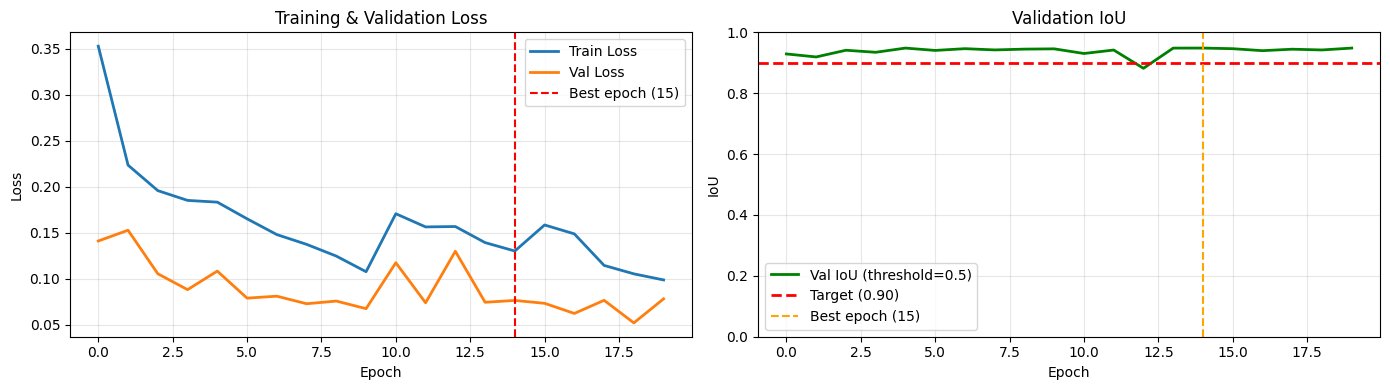

Training curves saved


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss curves
axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[0].axvline(history['best_epoch']-1, color='red', linestyle='--', label=f'Best epoch ({history["best_epoch"]})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# IoU curve
axes[1].plot(history['val_iou'], label='Val IoU (threshold=0.5)', linewidth=2, color='green')
axes[1].axhline(0.90, color='red', linestyle='--', label='Target (0.90)', linewidth=2)
axes[1].axvline(history['best_epoch']-1, color='orange', linestyle='--', label=f'Best epoch ({history["best_epoch"]})')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('IoU')
axes[1].set_title('Validation IoU')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1.0])

plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / 'training_curves.png', dpi=100, bbox_inches='tight')
plt.show()

print('Training curves saved')

## Training Summary

In [16]:
print('Analyzing worst-performing test images...\n')

# Re-evaluate test set with per-image IoU tracking
worst_ious = []
test_ious_per_image = []

model.eval()
with torch.no_grad():
    img_idx = 0
    for images, masks in tqdm(test_loader, desc='Collecting per-image IoU'):
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        pred_sigmoid = torch.sigmoid(outputs).cpu().numpy()
        mask_np = masks.cpu().numpy()

        for pred, target in zip(pred_sigmoid, mask_np):
            pred_binary = (pred.squeeze() > best_threshold).astype(np.uint8)
            target_binary = (target.squeeze() > 0.5).astype(np.uint8)
            iou = iou_score(pred_binary, target_binary)

            img_path, mask_path = test_pairs[img_idx]
            test_ious_per_image.append({
                'idx': img_idx,
                'img_path': img_path,
                'mask_path': mask_path,
                'iou': iou
            })
            worst_ious.append((img_idx, iou, img_path, mask_path))
            img_idx += 1

# Sort by IoU
worst_ious.sort(key=lambda x: x[1])

print(f'Worst 10 test images:\n')
print(f'{"Rank":<6} {"IoU":<8} {"Image Path (last 40 chars)"}')
print('-' * 60)

for rank, (idx, iou, img_path, mask_path) in enumerate(worst_ious[:10], 1):
    path_short = img_path[-40:] if len(img_path) > 40 else img_path
    print(f'{rank:<6} {iou:<8.4f} {path_short}')

print(f'\nStatistics:')
print(f'  Min IoU   : {worst_ious[0][1]:.4f} (image {worst_ious[0][0]})')
print(f'  Max IoU   : {worst_ious[-1][1]:.4f} (image {worst_ious[-1][0]})')
print(f'  Median IoU: {np.median([x[1] for x in worst_ious]):.4f}')
print(f'  Q1 IoU    : {np.percentile([x[1] for x in worst_ious], 25):.4f}')
print(f'  Q3 IoU    : {np.percentile([x[1] for x in worst_ious], 75):.4f}')

# Check distribution by dataset source
print(f'\nDataset source analysis:')
sources = {'masonry': 0, 'crackforest': 0, 'omnicrack': 0, 'historical': 0}
for idx, iou, img_path, mask_path in worst_ious[:20]:
    if 'masonry' in img_path:
        sources['masonry'] += 1
    elif 'crackforest' in img_path:
        sources['crackforest'] += 1
    elif 'omnicrack' in img_path or 'images/' in img_path:
        sources['omnicrack'] += 1
    elif 'historical' in img_path:
        sources['historical'] += 1

print('Worst 20 test images source:')
for source, count in sources.items():
    print(f'  {source}: {count}')

print(f'\nTo visualize worst images, load and display:')
print(f'worst_idx = worst_ious[0][0]  # Index of worst image')
print(f'img_path, mask_path = test_pairs[worst_idx]')
print(f'img = cv2.imread(img_path)')
print(f'mask = cv2.imread(mask_path, 0)')

Analyzing worst-performing test images...



Worst 10 test images:

Rank   IoU      Image Path (last 40 chars)
------------------------------------------------------------
1      0.0037   /content/data/crackforest/images/049.jpg
2      0.0064   /content/data/crackforest/images/015.jpg
3      0.0090   /content/data/crackforest/images/053.jpg
4      0.0091   /content/data/crackforest/images/103.jpg
5      0.0092   /content/data/crackforest/images/094.jpg
6      0.0099   /content/data/crackforest/images/052.jpg
7      0.0101   /content/data/crackforest/images/033.jpg
8      0.0112   /content/data/crackforest/images/045.jpg
9      0.0113   /content/data/crackforest/images/026.jpg
10     0.0121   /content/data/crackforest/images/001.jpg

Statistics:
  Min IoU   : 0.0037 (image 432)
  Max IoU   : 1.0000 (image 462)
  Median IoU: 0.9911
  Q1 IoU    : 0.9739
  Q3 IoU    : 0.9985

Dataset source analysis:
Worst 20 test images source:
  masonry: 0
  crackforest: 20
  omnicrack: 0
  historical: 0

To visualize worst images, load and display